In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import time

import warnings
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

## Duomenų paruošimas

In [2]:
from ucimlrepo import fetch_ucirepo

breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 

X = breast_cancer_wisconsin_original.data.features 
y = breast_cancer_wisconsin_original.data.targets 

df = pd.concat([X, y], axis=1)

### Atributų duomenų tvarkymas

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


- Matome, kad kintamieji yra gero formato: visi skaitiniai sveikieji/realieji, kaip ir turėtų būti.
- Matome, kad yra trūkstamų reikšmių kintamajame `Bare_nuclei`

In [4]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

### Klasių duomenų tvarkymas

- Klasių koduotės taisymas: į 0 ir 1

In [5]:
def recode_class(class_code):
    if class_code == 2:
        return 0
    elif class_code == 4:
        return 1
    else:
        raise ValueError(f'Data is not correct. class_code: {class_code}, class_code type: {type(class_code)}')

In [6]:
df['Class'] = df['Class'].apply(recode_class)

### Tiriamosios analizės žingsniai

- Patikriname, ar nėra išskirčių, kurias reikėtų pašalinti.
- Ištiriame skaitines charakteristikas

In [7]:
df.groupby('Class').mean()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
Class,,,,,,,,,
0,2.963964,1.306306,1.414414,1.346847,2.108108,1.346847,2.083333,1.261261,1.065315
1,7.188285,6.577406,6.560669,5.585774,5.326360,7.627615,5.974895,5.857741,2.602510


In [8]:
df.groupby('Class').median()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
Class,,,,,,,,,
0,3.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0
1,8.0,6.0,6.0,5.0,5.0,10.0,7.0,6.0,1.0


### Duomenų vizualizavimas, pasitelkus PCA

In [9]:
from sklearn.decomposition import PCA

In [10]:
X_transformed = PCA(n_components=2)\
    .fit_transform(df.drop(columns=['Class']))

X_transformed = pd.DataFrame(X_transformed, columns=['x', 'y'])
y_transformed = df['Class'].reset_index(drop=True)

df_transformed = pd.concat( [X_transformed, y_transformed], axis=1 )

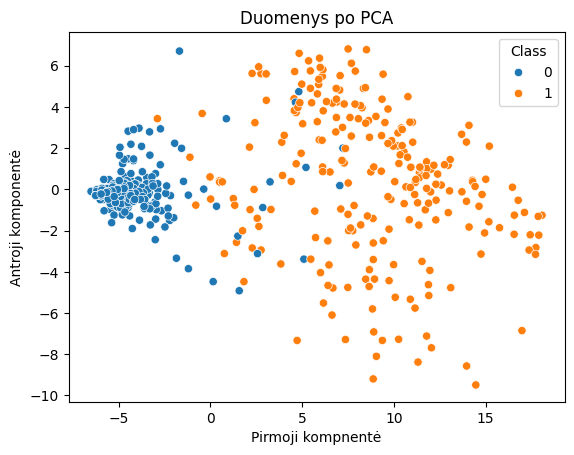

In [11]:
sns.scatterplot(data=df_transformed, x='x', y='y', hue='Class')

plt.xlabel('Pirmoji kompnentė')
plt.ylabel('Antroji komponentė')
plt.title('Duomenys po PCA')

plt.show()

### Paskutiniai duomenų paruošimo žingsniai

- Permaišome duomenis
- Padalijame duomenis į treniravimo, validavimo ir testavimo rinkinius

In [12]:
df.index = np.random.permutation(df.index)
df.head(10)

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
413,5,1,1,1,2,1.0,3,1,1,0
166,5,4,4,5,7,10.0,3,2,1,0
356,3,1,1,1,2,2.0,3,1,1,0
525,6,8,8,1,3,4.0,3,7,1,0
521,4,1,1,3,2,1.0,3,1,1,0
544,8,10,10,8,7,10.0,9,7,1,1
51,1,1,1,1,2,10.0,3,1,1,0
28,2,1,2,1,2,1.0,3,1,1,0
635,2,1,1,1,2,1.0,1,1,5,0
146,4,2,1,1,2,1.0,2,1,1,0


In [13]:
X = df.drop(columns=['Class'])
y = df['Class']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
train_ratio = 0.8
validation_ratio = 0.1
test_ratio = 0.1

# Kodas iš stackoverflow https://datascience.stackexchange.com/questions/15135/train-test-validation-set-splitting-in-sklearn:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio)) 

print(X_train.shape, X_val.shape, X_test.shape)

(546, 9) (68, 9) (69, 9)


# Neurono implementacija

In [16]:
AKTIVACIJOS_FUNKCIJOS = {
    'slenkstine': lambda x: 1 if x >= 0 else 0,
    'sigmoidine': lambda x: 1 / (1 + np.exp(-1 * x))
}

In [17]:
class PaprastasNeuronas:
    def __init__(self, activation: str):
        assert activation in AKTIVACIJOS_FUNKCIJOS,\
            'Pateikite sigmodine arba slekstine aktyvacijos funkcija'

        self.activation = AKTIVACIJOS_FUNKCIJOS[activation]
        self.initialize_weights()

    def initialize_weights(self):
        """ Inicializuojami svoriai pagal Xavier incializaciją. n - 9 """
        np.random.seed(42)
        self.weights = np.random.uniform( low = -1/3, high = 1/3, size = (9,) )
        self.b = 0

    def set_weights(self, weights: np.ndarray, bias: float):
        self.weights = weights 
        self.b = bias

    def __call__(self, x: np.ndarray):
        a = np.dot( self.weights, x )
        z = self.activation(a)
        return z

    def predict(self, x: np.ndarray):
        return 1 if self(x) >= 0.5 else 0

In [18]:
def evaluate_dataset(self, X: pd.DataFrame) -> np.array:
    outputs = []

    for x_input_pd in X.iterrows():
        x_input = x_input_pd[1].values
        outputs.append( self(x_input) )

    return np.array(outputs)

setattr(PaprastasNeuronas, 'evaluate_dataset', evaluate_dataset)

In [19]:
def update_history(
    self,
    history: dict,
    t: pd.Series,
    y: np.ndarray,
    t_val: pd.Series,
    y_val: np.ndarray
):
    # total error
    history['Treniravimo RMSE'].append(
        np.mean( (y - t.values) ** 2))

    history['Validavimo RMSE'].append(
        np.mean((y_val - t_val.values) ** 2))

    # accuracy
    history['Treniravimo tikslumas'].append(
        np.mean( (y >= 0.5) == t.values ))

    history['Validavimo tikslumas'].append(
        np.mean( (y_val >= 0.5) == t_val.values ))

    return history

setattr(PaprastasNeuronas, 'update_history', update_history)

In [20]:
def backpropagate_sgd(
    self,
    X: pd.DataFrame,
    t: pd.Series,
    X_val: pd.DataFrame,
    t_val: pd.Series,
    lr: float = 1e-3,
    epochs: int = 50,
    e_min: float = 50
):
    total_error = np.inf
    epoch = 0

    n, m = X.shape
    total_time = 0

    history = {
        'Treniravimo RMSE': [],
        'Validavimo RMSE': [],
        'Treniravimo tikslumas': [],
        'Validavimo tikslumas': []
    }

    while total_error > e_min and epoch < epochs:

        start = time.time()
        total_error = 0
        y = self.evaluate_dataset(X)
        y_val = self.evaluate_dataset(X_val)

        for i in range(n):

            y_i = y[i]
            t_i = t.values[i]

            x_i = X.iloc[i, :].values
            update = (y_i - t_i) * y_i * (1 - y_i) * x_i
            self.weights -= lr * update

            total_error += (y_i - t_i) ** 2

        epoch += 1
        end = time.time()

        total_time += end - start
        history = self.update_history(history, t, y, t_val, y_val)

    return history, total_time

setattr(PaprastasNeuronas, 'backpropagate_sgd', backpropagate_sgd)

In [21]:
neuronas_sgd = PaprastasNeuronas('sigmoidine')
history_sgd, time_sgd = neuronas_sgd.backpropagate_sgd(X_train, y_train, X_val, y_val)

print("Treniruotės laikas:", time_sgd, "s")

Treniruotės laikas: 1.2451808452606201 s


In [22]:
sgd_history_df = pd.DataFrame(history_sgd)

In [23]:
y_pred = [neuronas_sgd.predict(x_in[1].values) for x_in in X_test.iterrows()]
y_true = y_test

np.mean( y_pred == y_true )

np.float64(0.8985507246376812)

In [24]:
def backpropagate_paketinis(
    self,
    X: pd.DataFrame,
    t: pd.Series,
    X_val: pd.DataFrame,
    t_val: pd.Series,
    lr: float = 1e-3,
    epochs: int = 50,
    e_min: float = 50
):
    total_error = np.inf
    epoch = 0

    n, m = X.shape
    total_time = 0

    history = {
        'Treniravimo RMSE': [],
        'Validavimo RMSE': [],
        'Treniravimo tikslumas': [],
        'Validavimo tikslumas': []
    }
    
    while total_error > e_min and epoch < epochs:

        start = time.time()
        total_error = 0

        y = self.evaluate_dataset(X)
        y_val = self.evaluate_dataset(X_val)

        gradient_sum = np.zeros((9,))
        for i in range(n):

            y_i = y[i]
            t_i = t.values[i]

            x_i = X.iloc[i, :].values
            gradient_sum += (y_i - t_i) * y_i * (1 - y_i) * x_i

            total_error += (y_i - t_i) ** 2

        self.weights -= lr * gradient_sum / n
    
        end = time.time()
        total_time += end - start

        history = self.update_history(history, t, y, t_val, y_val)
        epoch += 1

    return history, total_time

setattr(PaprastasNeuronas, 'backpropagate_paketinis', backpropagate_paketinis)

In [25]:
neuronas_batch = PaprastasNeuronas('sigmoidine')
history_batch, time_batch = neuronas_batch.backpropagate_paketinis(X_train, y_train, X_val, y_val)

print("Treniruotės laikas:", time_batch, "s")

Treniruotės laikas: 1.1959116458892822 s


In [26]:
y_pred = [neuronas_batch.predict(x_in[1].values) for x_in in X_test.iterrows()]
y_true = y_test

np.mean( y_pred == y_true )

np.float64(0.7536231884057971)

In [27]:
batch_history_df = pd.DataFrame(history_batch)

# Analizė

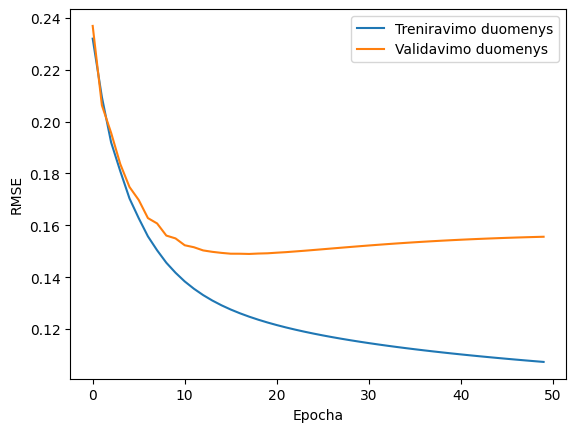

<Figure size 640x480 with 0 Axes>

In [28]:
plt.plot(sgd_history_df['Treniravimo RMSE'], label='Treniravimo duomenys')
plt.plot(sgd_history_df['Validavimo RMSE'], label='Validavimo duomenys')

plt.xlabel('Epocha')
plt.ylabel('RMSE')

plt.legend()
plt.show()
plt.savefig('RMSE_fig.png', dpi=2000)

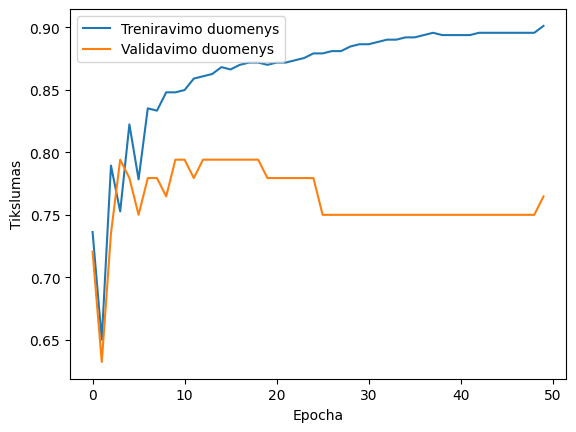

<Figure size 640x480 with 0 Axes>

In [29]:
plt.plot(sgd_history_df['Treniravimo tikslumas'], label='Treniravimo duomenys')
plt.plot(sgd_history_df['Validavimo tikslumas'], label='Validavimo duomenys')

plt.xlabel('Epocha')
plt.ylabel('Tikslumas')

plt.legend()
plt.show()
plt.savefig('acc_fig.png', dpi=2000)

In [30]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]

accuracies_sgd = []
accuracies_batch = []

for lr in learning_rates:
    neuronas = PaprastasNeuronas('sigmoidine')
    _ = neuronas.backpropagate_sgd(X_train, y_train, X_val, y_val, lr=lr)

    y_true = y_test
    y_pred = neuronas.evaluate_dataset(X_test)

    acc = np.mean( (y_pred >= 0.5) == y_true )
    accuracies_sgd.append( acc)
    
    neuronas = PaprastasNeuronas('sigmoidine')
    _ = neuronas.backpropagate_paketinis(X, y, X_val, y_val, lr=lr)

    y_true = y_train
    y_pred = neuronas.evaluate_dataset(X_train)

    acc = np.mean( (y_pred >= 0.5) == y_true )
    accuracies_batch.append( acc)

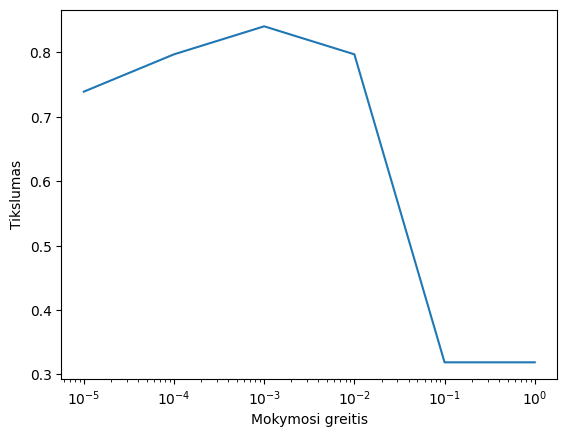

<Figure size 640x480 with 0 Axes>

In [31]:
plt.semilogx(learning_rates, accuracies_sgd)

plt.ylabel('Tikslumas')
plt.xlabel('Mokymosi greitis')

plt.show()
plt.savefig('lr_sgd.png', dpi=2000)

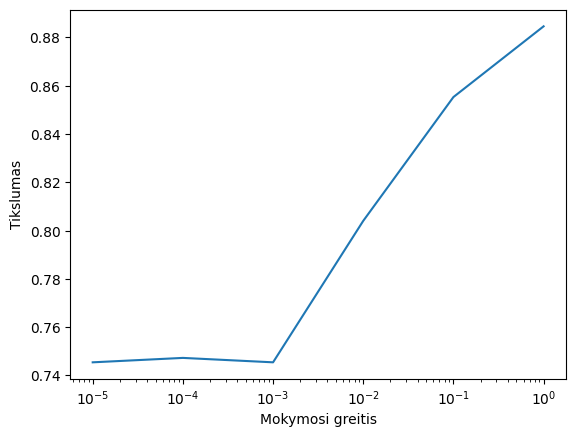

<Figure size 640x480 with 0 Axes>

In [32]:
plt.semilogx(learning_rates, accuracies_batch)

plt.ylabel('Tikslumas')
plt.xlabel('Mokymosi greitis')

plt.show()
plt.savefig('lr_batch.png', dpi=2000)

In [33]:
output = {
    'Tipas': [],
    'Laikas': []
}

for i in range(40):

    neuronas = PaprastasNeuronas('sigmoidine')
    
    if i % 2 == 0:
        output['Tipas'].append('Stochastinis')
        _, time_spent = neuronas.backpropagate_sgd(X_train, y_train, X_val, y_val, lr=1e-3)

    else:
        output['Tipas'].append('Paketinis')
        _, time_spent = neuronas.backpropagate_paketinis(X_train, y_train, X_val, y_val, lr=1e-1)

    output['Laikas'].append(time_spent)

In [34]:
output = pd.DataFrame(output)

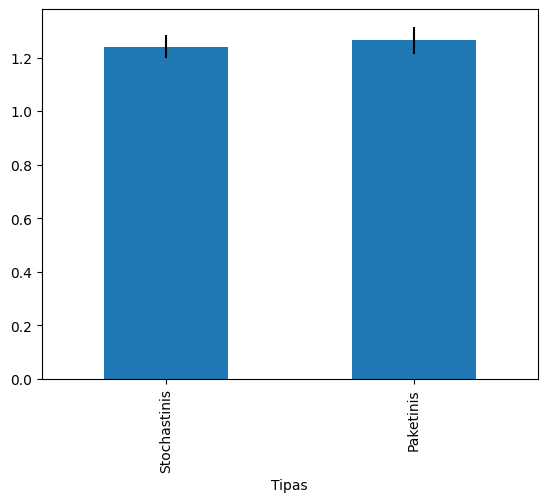

<Figure size 640x480 with 0 Axes>

In [35]:
df_laikas = pd.DataFrame({'Tipas': output['Tipas'].unique()})

df_laikas['Laikas'] = output.groupby('Tipas')['Laikas'].mean().values
df_laikas['yerr'] = 2 * output.groupby('Tipas')['Laikas'].std().values

df_laikas.plot(kind='bar', x='Tipas', y='Laikas', yerr='yerr', legend=False)

plt.show()
plt.savefig('laikas.png', dpi=2000)

In [36]:
output = {
    'Tipas': [],
    'Paklaida': [],
    'Tikslumas': []
}

In [37]:
output['Tipas'].append( 'Stochastine' )

neuronas = PaprastasNeuronas('sigmoidine')
_, _ = neuronas.backpropagate_sgd(X_train, y_train, X_val, y_val, lr=1e-3)

y_pred = neuronas.evaluate_dataset(X_test)
y_true = y_test

acc = np.mean( (y_pred >= 0.5) == y_true )
output['Tikslumas'].append( acc )

loss = np.mean( (y_true - y_pred) ** 2 )
output['Paklaida'].append( loss )

In [38]:
output['Tipas'].append( 'Paketinis' )

neuronas = PaprastasNeuronas('sigmoidine')
_, _ = neuronas.backpropagate_paketinis(X_train, y_train, X_val, y_val, lr=1e-3)

y_pred = neuronas.evaluate_dataset(X_test)
y_true = y_test

acc = np.mean( (y_pred >= 0.5) == y_true )
output['Tikslumas'].append( acc )

loss = np.mean( (y_true - y_pred) ** 2 )
output['Paklaida'].append( loss )

In [39]:
output = pd.DataFrame( output )

Text(0, 0.5, 'Tikslumas')

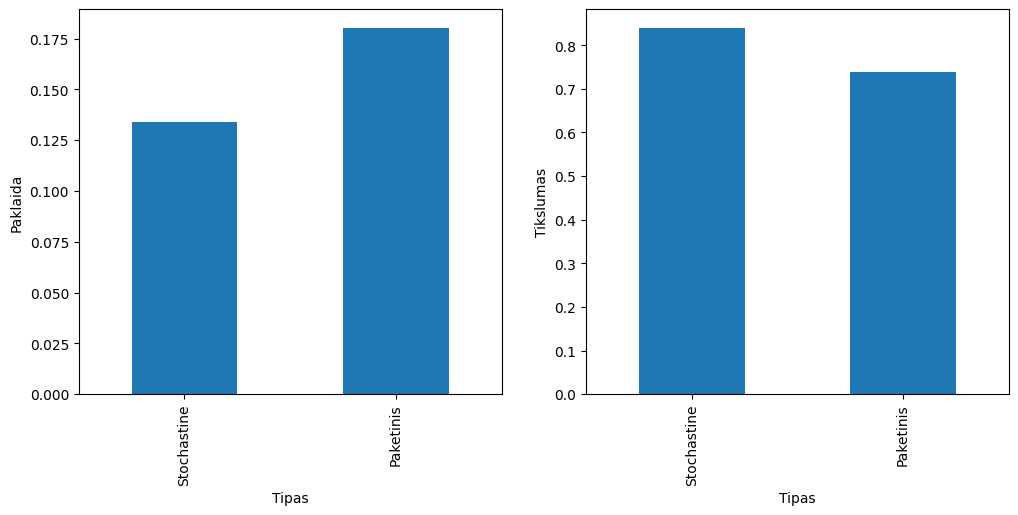

In [41]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

output.plot(kind='bar', x='Tipas', y='Paklaida', ax=axs[0], legend=False)
axs[0].set_ylabel('Paklaida')

output.plot(kind='bar', x='Tipas', y='Tikslumas', ax=axs[1], legend=False)
axs[1].set_ylabel('Tikslumas')